# Cyberbullying Detection using NLP & Machine Learning

A multi-class text classification pipeline that detects and categorizes cyberbullying in tweets using **TF-IDF** features and three classic ML models: **Logistic Regression**, **Random Forest**, and **XGBoost**.

**Dataset:** [Cyberbullying Classification (Kaggle)](https://www.kaggle.com/datasets/andrewmvd/cyberbullying-classification) — ~47,000 tweets labeled into 6 balanced categories:
`age`, `ethnicity`, `gender`, `religion`, `other_cyberbullying`, `not_cyberbullying`.

**Pipeline overview**
1. Load & inspect the dataset
2. Exploratory Data Analysis (EDA)
3. Text preprocessing / cleaning
4. TF-IDF feature extraction
5. Train & evaluate Logistic Regression, Random Forest, and XGBoost
6. Compare model performance
7. Save the best model for reuse
8. Quick demo: classify custom text

---


## 0. Setup

Install/import all required libraries.

In [1]:
# Install any packages not already available in the environment.
# (Safe to re-run; pip will skip anything already satisfied.)
!pip install -q kagglehub xgboost wordcloud nltk


In [2]:
import os
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)
from xgboost import XGBClassifier
import joblib

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english"))

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load Dataset

The dataset is downloaded from Kaggle using [`kagglehub`](https://github.com/Kaggle/kagglehub).

- **On Kaggle Notebooks:** the dataset is likely already mounted at `/kaggle/input/...` — the code below finds it automatically.
- **On Colab / locally:** `kagglehub` will prompt for Kaggle API authentication the first time (you'll need a `kaggle.json` API token, or Colab's built-in Kaggle login flow). See the [kagglehub docs](https://github.com/Kaggle/kagglehub) if you hit an auth error.
- **Fallback:** if you already have the CSV, just place it in the working directory as `cyberbullying_tweets.csv` and the loader below will pick it up.


In [3]:
def load_cyberbullying_dataset():
    """Load the Cyberbullying Classification dataset from Kaggle,
    with a local-file fallback for environments without Kaggle auth."""
    local_path = "cyberbullying_tweets.csv"
    if os.path.exists(local_path):
        return pd.read_csv(local_path)

    try:
        import kagglehub

        dataset_path = kagglehub.dataset_download(
            "andrewmvd/cyberbullying-classification"
        )
        for fname in os.listdir(dataset_path):
            if fname.endswith(".csv"):
                return pd.read_csv(os.path.join(dataset_path, fname))
        raise FileNotFoundError("No CSV found in downloaded dataset folder.")
    except Exception as e:
        raise RuntimeError(
            "Could not load the dataset automatically. "
            "Download 'cyberbullying_tweets.csv' from "
            "https://www.kaggle.com/datasets/andrewmvd/cyberbullying-classification "
            "and place it in the working directory, or set up Kaggle API "
            f"credentials for kagglehub. Original error: {e}"
        )


df = load_cyberbullying_dataset()

# Standardize column names across dataset versions
df = df.rename(columns={df.columns[0]: "text", df.columns[1]: "label"})
df = df.dropna(subset=["text", "label"]).drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (46017, 2)


,text,label
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


## 2. Exploratory Data Analysis

Class distribution:

label
religion               7995
age                    7992
ethnicity              7952
not_cyberbullying      7937
gender                 7898
other_cyberbullying    6243
Name: count, dtype: int64


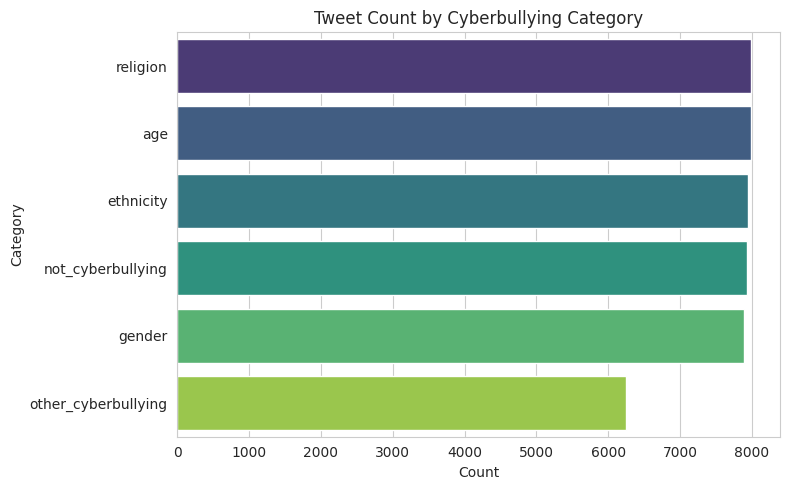

In [4]:
print("Class distribution:\n")
print(df["label"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, y="label", order=df["label"].value_counts().index, palette="viridis")
plt.title("Tweet Count by Cyberbullying Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


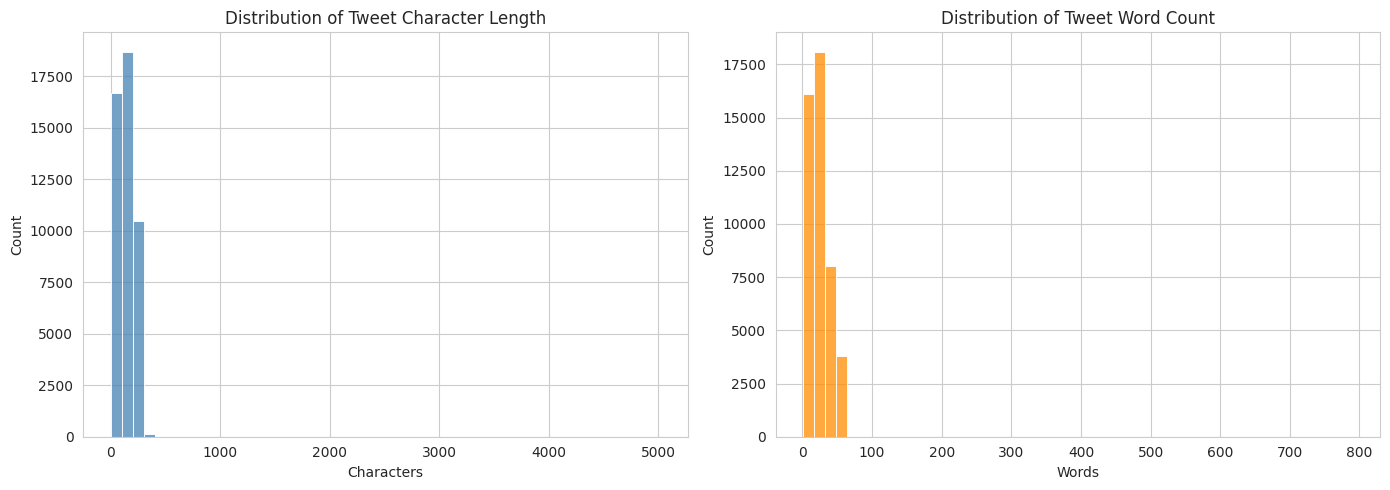

        text_length    word_count
count  46017.000000  46017.000000
mean     138.108134     24.059804
std       85.863595     15.537983
min        1.000000      1.000000
25%       80.000000     13.000000
50%      125.000000     21.000000
75%      187.000000     33.000000
max     5018.000000    790.000000


In [5]:
df["text_length"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["text_length"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Tweet Character Length")
axes[0].set_xlabel("Characters")

sns.histplot(df["word_count"], bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Tweet Word Count")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

print(df[["text_length", "word_count"]].describe())


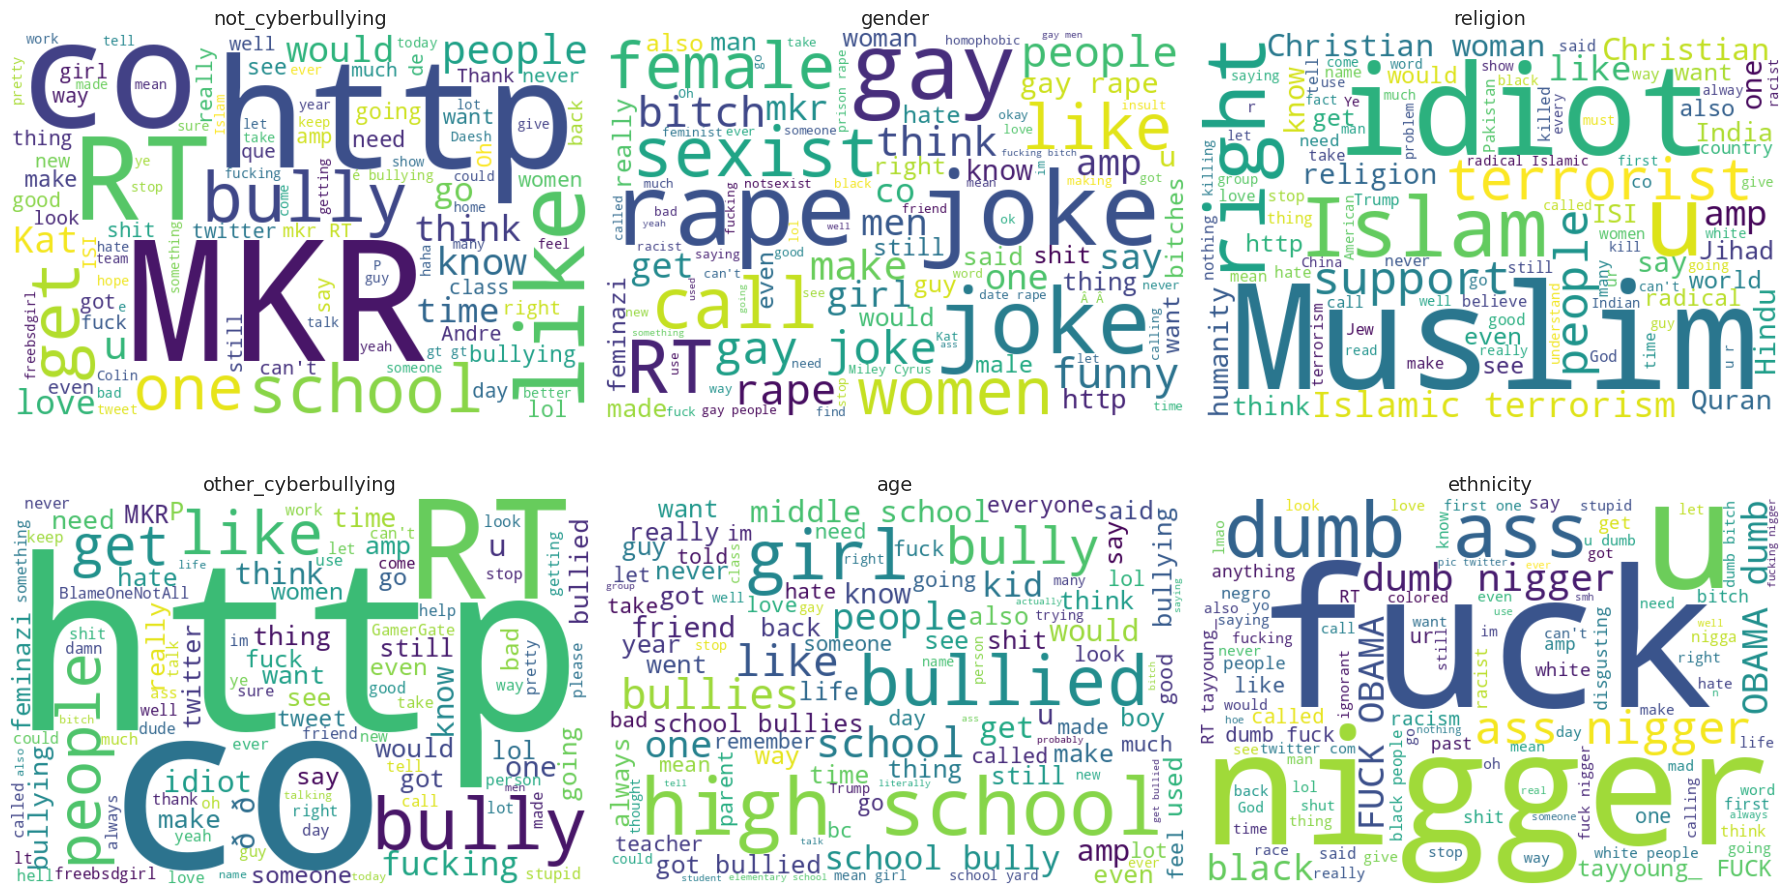

In [6]:
# Word clouds per category give a quick qualitative feel for each class
categories = df["label"].unique()
n_cols = 3
n_rows = int(np.ceil(len(categories) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, cat in enumerate(categories):
    text_blob = " ".join(df.loc[df["label"] == cat, "text"].astype(str).tolist())
    wc = WordCloud(width=600, height=400, background_color="white",
                   stopwords=STOPWORDS, max_words=100).generate(text_blob)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(cat, fontsize=14)
    axes[i].axis("off")

for j in range(len(categories), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


## 3. Text Preprocessing

Standard NLP cleaning steps before vectorization:
- Lowercase
- Remove URLs, @mentions, and the `#` symbol (keep hashtag words)
- Remove punctuation and digits
- Remove stopwords
- Collapse extra whitespace


In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # URLs
    text = re.sub(r"@\w+", " ", text)                       # mentions
    text = re.sub(r"#", " ", text)                           # hashtag symbol (keep word)
    text = re.sub(r"[^a-z\s]", " ", text)                    # punctuation/digits
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

df[["text", "clean_text", "label"]].sample(5, random_state=RANDOM_STATE)


,text,clean_text,label
7725,"but now, time to ready myself for my 3 year ol...",time ready year old whorl wind come demand fir...,not_cyberbullying
949,@elplatt @TheQuinnspiracy babies,babies,not_cyberbullying
38089,Y’all see all these niggers trying to justify ...,see niggers trying justify celebrating white h...,ethnicity
42072,"@Bo_OYoww: “@tayyoung_: FUCK OBAMA, dumb ass n...",fuck obama dumb ass nigger amp guess mad cuz l...,ethnicity
27091,"oh, this is bad. this is really, really bad. C...",bad really really bad sexual assault comics he...,other_cyberbullying


## 4. Feature Engineering — TF-IDF

We convert cleaned text into numerical features using **TF-IDF** (Term Frequency–Inverse Document Frequency), capturing both unigrams and bigrams.


In [8]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape:  {X_test_tfidf.shape}")

# XGBoost needs numeric labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
class_names = label_encoder.classes_


Train shape: (36475, 10000)
Test shape:  (9119, 10000)


## 5. Model Training & Evaluation

In [9]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, target_names):
    """Fit a model, print a classification report, plot a confusion matrix,
    and store summary metrics in the global `results` dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_te, y_pred, average="macro", zero_division=0
    )

    print(f"### {name} ###")
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_te, y_pred, target_names=target_names, zero_division=0))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    results[name] = {
        "model": model,
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }
    return model


### 5.1 Logistic Regression

### Logistic Regression ###
Accuracy: 0.8471

                     precision    recall  f1-score   support

                age       0.96      0.98      0.97      1599
          ethnicity       0.97      0.98      0.97      1590
             gender       0.92      0.86      0.89      1573
  not_cyberbullying       0.65      0.62      0.63      1555
other_cyberbullying       0.57      0.67      0.61      1203
           religion       0.97      0.94      0.95      1599

           accuracy                           0.85      9119
          macro avg       0.84      0.84      0.84      9119
       weighted avg       0.85      0.85      0.85      9119



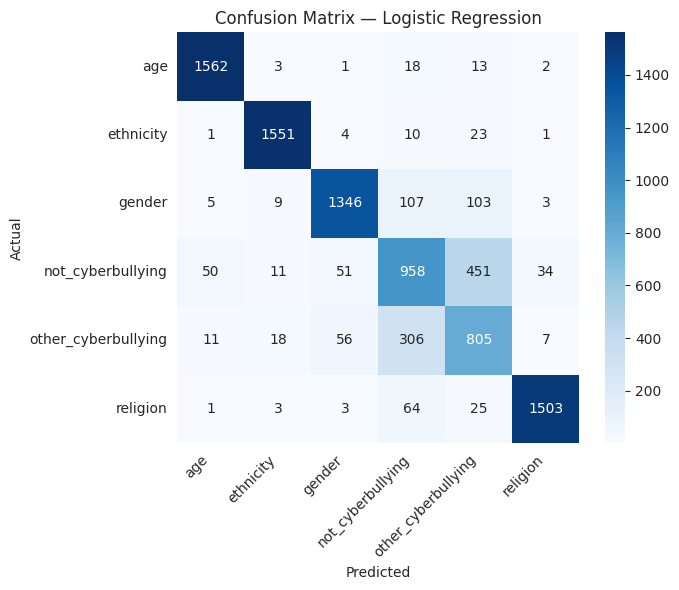

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [10]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
evaluate_model("Logistic Regression", log_reg, X_train_tfidf, y_train, X_test_tfidf, y_test, class_names)


### 5.2 Random Forest

### Random Forest ###
Accuracy: 0.8537

                     precision    recall  f1-score   support

                age       0.98      0.98      0.98      1599
          ethnicity       0.99      0.98      0.99      1590
             gender       0.90      0.87      0.89      1573
  not_cyberbullying       0.66      0.63      0.65      1555
other_cyberbullying       0.58      0.65      0.61      1203
           religion       0.96      0.95      0.96      1599

           accuracy                           0.85      9119
          macro avg       0.85      0.84      0.84      9119
       weighted avg       0.86      0.85      0.86      9119



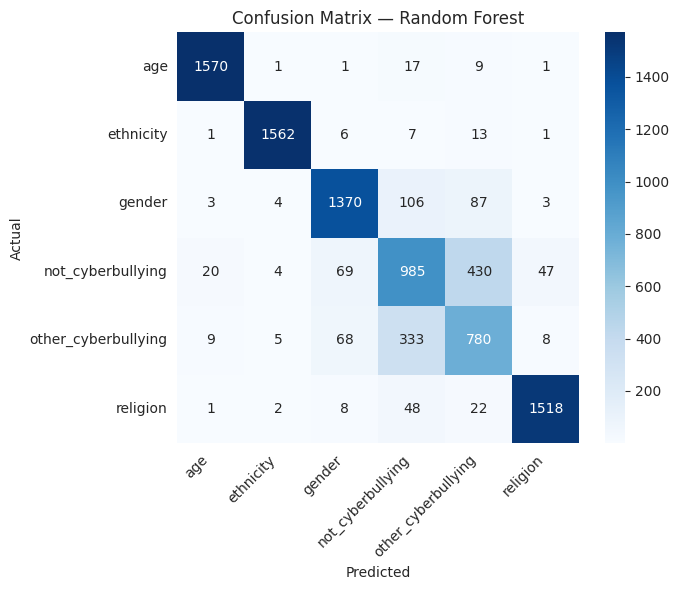

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [11]:
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=None, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
evaluate_model("Random Forest", rf_clf, X_train_tfidf, y_train, X_test_tfidf, y_test, class_names)


### 5.3 XGBoost

### XGBoost ###
Accuracy: 0.8513

                     precision    recall  f1-score   support

                age       0.99      0.97      0.98      1599
          ethnicity       0.99      0.99      0.99      1590
             gender       0.92      0.87      0.89      1573
  not_cyberbullying       0.60      0.74      0.66      1555
other_cyberbullying       0.60      0.53      0.56      1203
           religion       0.97      0.94      0.95      1599

           accuracy                           0.85      9119
          macro avg       0.85      0.84      0.84      9119
       weighted avg       0.86      0.85      0.85      9119



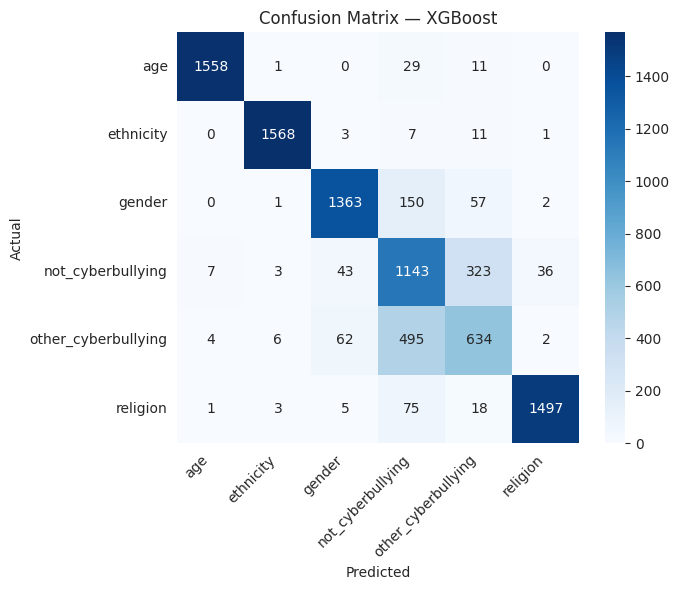

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1, num_class=6, ...)

In [13]:
xgb_clf = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.2,
    objective="multi:softmax", num_class=len(class_names),
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
)
evaluate_model("XGBoost", xgb_clf, X_train_tfidf, y_train_enc, X_test_tfidf, y_test_enc, class_names)


## 6. Model Comparison

,accuracy,precision_macro,recall_macro,f1_macro
Logistic Regression,0.8471,0.8406,0.8389,0.8387
Random Forest,0.8537,0.8451,0.8444,0.8444
XGBoost,0.8513,0.8473,0.8375,0.8407


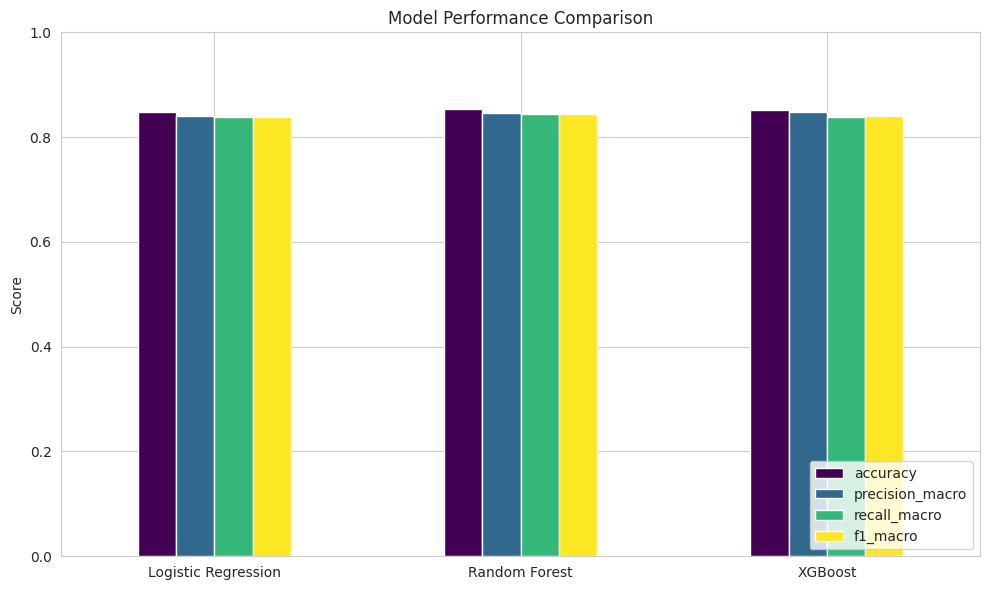


Best model (by macro F1-score): Random Forest


In [14]:
comparison_df = pd.DataFrame(results).T[["accuracy", "precision_macro", "recall_macro", "f1_macro"]]
comparison_df = comparison_df.astype(float).round(4)
display(comparison_df)

comparison_df.plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_model_name = comparison_df["f1_macro"].idxmax()
print(f"\nBest model (by macro F1-score): {best_model_name}")


## 7. Save Best Model

Persist the winning model along with the TF-IDF vectorizer (and label encoder, needed if XGBoost wins) so it can be reloaded without retraining.


In [15]:
os.makedirs("artifacts", exist_ok=True)

best_model = results[best_model_name]["model"]
joblib.dump(best_model, f"artifacts/best_model_{best_model_name.replace(' ', '_').lower()}.joblib")
joblib.dump(tfidf, "artifacts/tfidf_vectorizer.joblib")
joblib.dump(label_encoder, "artifacts/label_encoder.joblib")

print("Saved artifacts:")
print(os.listdir("artifacts"))


Saved artifacts:
['tfidf_vectorizer.joblib', 'best_model_random_forest.joblib', 'label_encoder.joblib']


## 8. Quick Demo — Classify Custom Text

In [16]:
def predict_cyberbullying(text, model_name=best_model_name):
    model = results[model_name]["model"]
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    # XGBoost returns an encoded label; everything else returns the original string
    if isinstance(pred, (int, np.integer)):
        pred = label_encoder.inverse_transform([pred])[0]
    return pred


sample_texts = [
    "You are such an idiot, go back to your own country!",
    "Just finished my homework, feeling great about tomorrow's exam!",
    "Girls shouldn't be allowed to play this game, they're all terrible at it.",
]

for t in sample_texts:
    print(f"Text: {t}\nPredicted category: {predict_cyberbullying(t)}\n")


Text: You are such an idiot, go back to your own country!
Predicted category: other_cyberbullying

Text: Just finished my homework, feeling great about tomorrow's exam!
Predicted category: not_cyberbullying

Text: Girls shouldn't be allowed to play this game, they're all terrible at it.
Predicted category: gender



## 9. Conclusion

This notebook built an end-to-end NLP pipeline for multi-class cyberbullying detection:

- **Preprocessing:** cleaned raw tweets (URLs, mentions, punctuation, stopwords).
- **Features:** TF-IDF (unigrams + bigrams, 10,000 features).
- **Models:** Logistic Regression, Random Forest, and XGBoost were trained and compared using accuracy, precision, recall, and macro F1-score.
- **Result:** the comparison table/chart in Section 6 shows which model performed best on this dataset; the winning model and vectorizer are saved to `artifacts/` for reuse.

**Possible extensions**
- Hyperparameter tuning (`GridSearchCV` / `Optuna`)
- Try transformer-based embeddings (BERT/DistilBERT) as a stronger baseline
- Deploy the saved model behind a simple Flask/FastAPI endpoint
